Link Dasboard: https://public.tableau.com/views/Dashboard_M1_17623578649720/DashboardMilestone1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

## i. Introduction

Milestone 1

- Nama  : Adzan Aditya Gumilar

Program ini dibuat untuk menganalisis apakah latar belakang siswa dan pendidikan orang tua mempengaruhi performa dan hasil siswa pada ujian.

# ii. Problem Statement and Dataset Description

Dalam project Data Analyst kali ini saya mengangkat topik 'Kinerja Siswa SMA Dalam Ujian'.
Project ini di latar belakangi dengan adanya tingkat kemampuan siswa dalam melaksanakan ujian di tingkat SMA. Dapat di analisis korelasi antara latar belakang siswa SMA di Amerika Serikat dan pendidikan orangtua terhadap kinerja dan nilai ujian siswa di beberapa mata pelajaran.
Untuk Problem Statement yang didapat, berdasarkan dataset yang saya teliti yaitu untuk mengetahui apakah pendidikan orangtua dan latar belakang siswa mempengaruhi kinerja dan hasil ujian siswa SMA di Amerika Serikat. Problem Statement dijabarkan menggunakan SMART Framework sebagai berikut:
- SPECIFIC    : Mengetahui faktor apa saja yang mempengaruhi performa akademik siswa berdasar gender, pendidikan orang tua terhadap nilai ujian siswa.
- MEASURABLE  : Mengukur performa siswa melalui nilai math score, reading score, writing score, serta korelasi dan nilai terendah serta perbedaan nilai antar kategori.
- ACHIEVABLE  : Cara memperolehnya melalui dataset yang sudah disiapkan untuk dianalisis menggunakan python dan diolah datanya menggunakan grafik-grafik tertentu.
- RELEVANT    : Hasil analisis bermanfaat untuk memahami hubungan antara latar belakang siswa dan performa akademik, untuk meningkatkan strategi belajar siswa.
- Time-Bound  : Analisis diselesaikan dalam waktu kurang lebih 3 hari yang mencakup eksplorasi data dan analisis.


Dataset ini berjudul 'Students Performance in Exams'. Datasest ini berisi 1.000 data siswa dengan 8 kolom. Kumpulan data ini berisi nilai yang diperoleh siswa dalam berbagai mata pelajaran. Data terinspirasi untuk memahami pengaruh latar belakang orang tua, persiapan ujian, dll terhadap kinerja siswa di AMerika Serikat. Dataset berasal dari Kaggle: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams/data


# iii. Data Loading

In [2]:
# Proses data loading
import pandas as pd

df = pd.read_csv('P0M1_Adzan_Aditya_dataset.csv')

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# Eksplorasi data sederhana
print('Ukuran data:', df.shape)

# Untuk informasi kolom dan tipe data
df.info()

# Ringkasan bagian kolom numeric
df.describe()

Ukuran data: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Pada tahap data loading, data dimuat menggunakan read_csv() dari file dataset csv saya. Dataset terdiri dari 1000 entries dan berisi 8 kolom yang berisi atribut demografi siswa dan nilai ujian pada tiga mata pelajaran.

# iv. Data Cleaning

In [4]:
# Mengecek missing value
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Hasilnya tidak ada missing value. Artinya seluruh entries data terisi lengkap dan tidak memerlukan imputasi.

In [5]:
# Mengganti nama kolom dan merapikan huruf kapital

df.rename(columns={
  'gender': 'Gender',
  'race/ethnicity': 'Race_Ethnicity',
  'parental level of education': 'Parent_Education',
  'lunch': 'Lunch',
  'test preparation course': 'Test_Preparation',
  'math score': 'Math_Score',
  'reading score': 'Reading_Score',
  'writing score': 'Writing_Score'
}, inplace=True)

df.columns

df.head()

,Gender,Race_Ethnicity,Parent_Education,Lunch,Test_Preparation,Math_Score,Reading_Score,Writing_Score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Sekarang kolom lebih seragam menggunakan underscore(_).

In [6]:
# Cek apa ada data duplikat
duplicates = df.duplicated().sum()
print(duplicates)

0


Tidak ada data duplikat dalam dataset ini.

In [7]:
df.dtypes

Gender              object
Race_Ethnicity      object
Parent_Education    object
Lunch               object
Test_Preparation    object
Math_Score           int64
Reading_Score        int64
Writing_Score        int64
dtype: object

Tipe data sudah sesuai.

Dataset tidak ditemukan missing value, kolom duplikat, dan sudah dirapikan nama kolom. Dataset siap di Eksplorasi.

# v. Exploration and Analysis

In [8]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('P0M1_Adzan_Aditya_dataset.csv')

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Visualisasi Data

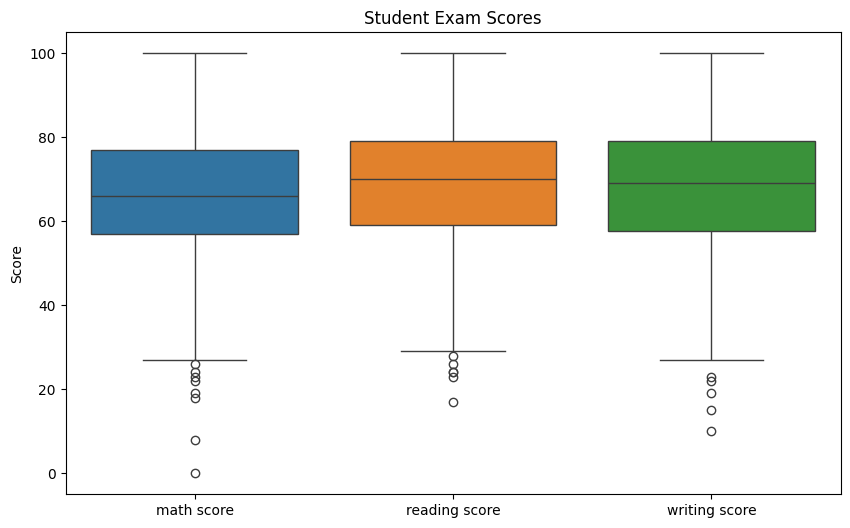

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['math score', 'reading score', 'writing score']])
plt.title('Student Exam Scores')
plt.ylabel('Score')
plt.show()


Menggunakan visualisasi data berupa multiple box plot karena ada 3 variabel.
Disini menunjukkan nilai reading dan writing lebih tinggi daripada math. Dalam data ini, siswa lebih unggul di kemampuan reading dan writing. Terdapat nilai outlier dibawah math score lebih banyak dibandingkan reading score dan writing score. Dari sini kita bisa lebih spesifik ke math score yang lebih rendah.

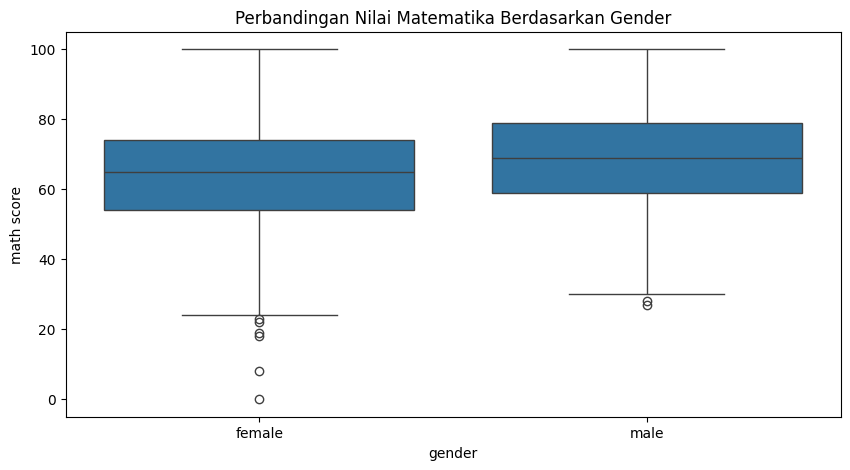

In [10]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='gender', y='math score')
plt.title('Perbandingan Nilai Matematika Berdasarkan Gender')
plt.show()

Menggunakan visualisasi dua multiple boxplot yaitu 'female' dan 'gender'.
Berdasarkan pada grafik sebelumnya menunjukkan math score yang lebih rendah, maka dari itu grafik diatas memberikan asumsi bahwa ada dugaan bahwa gender mungkin berpengaruh terhadap performa matematika.

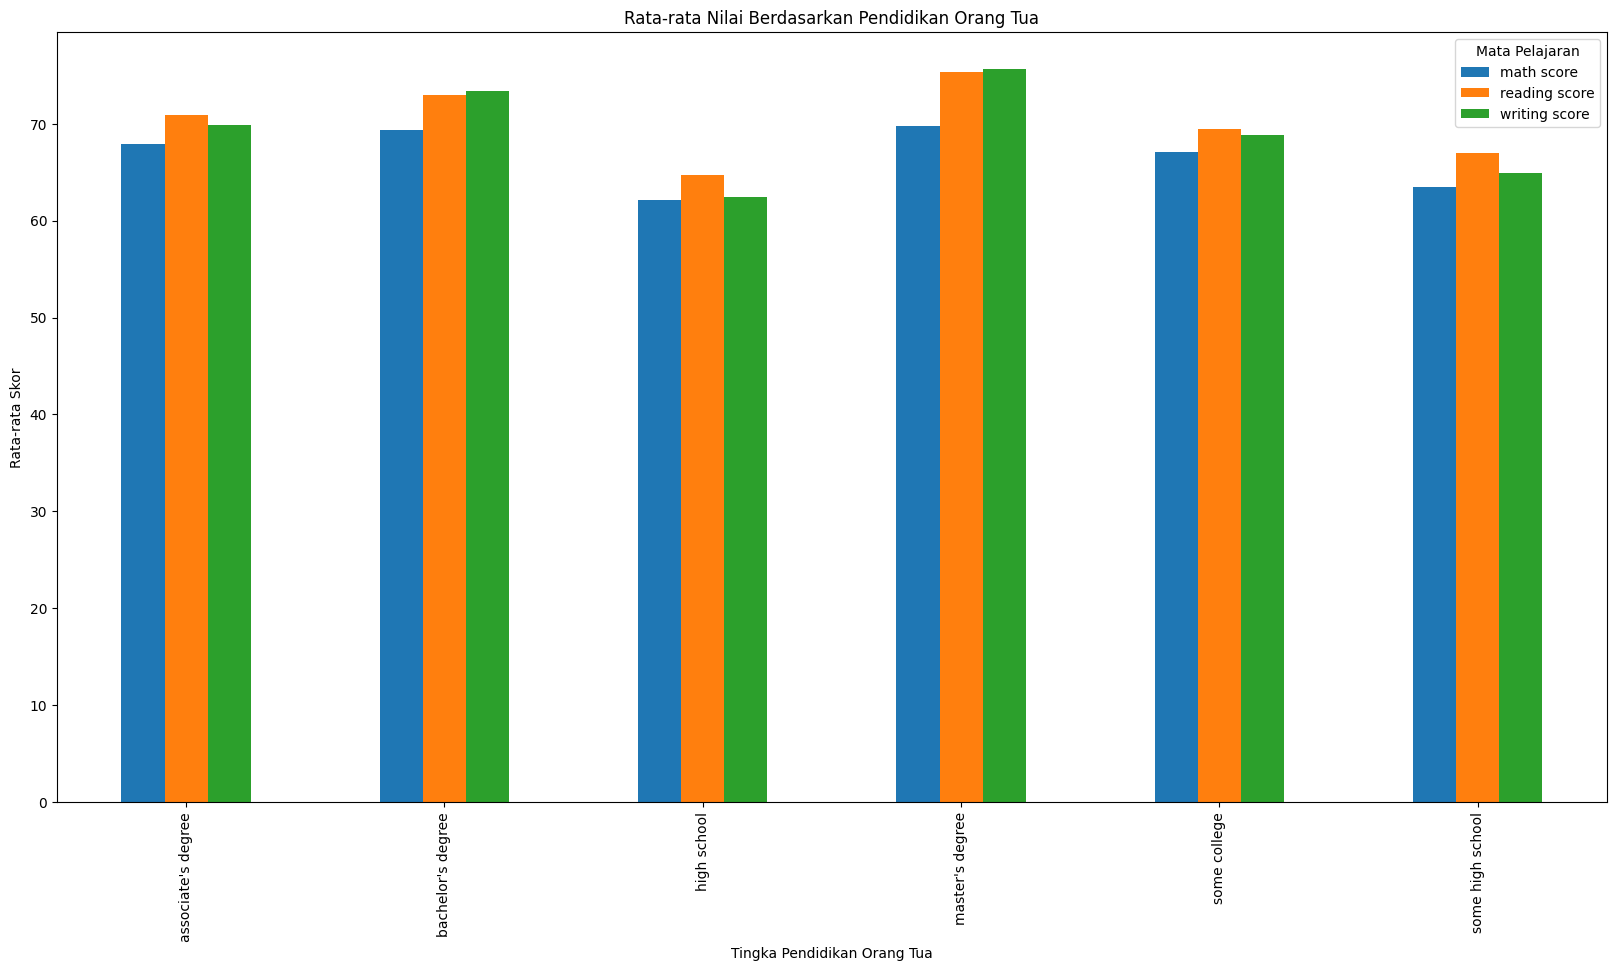

In [11]:
edu_scores = df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean().reset_index()

edu_scores.plot(x='parental level of education', kind='bar', figsize=(20,10))

plt.title('Rata-rata Nilai Berdasarkan Pendidikan Orang Tua')
plt.xlabel('Tingka Pendidikan Orang Tua')
plt.ylabel('Rata-rata Skor')
plt.legend(title='Mata Pelajaran')
plt.show()

Visualisasi menggunakan bar chart multiple category, untuk kategori mata pelajaran memiliki 3 warna berbeda. Disini kita tahu bahwa pendidikan orangtua sedikitnya memiliki pengaruh terhadap prestasi akademik siswa. Disini secara tidak langsung terbentuk pola bahwa pendidikan orangtua mempengaruhi nilai siswa.

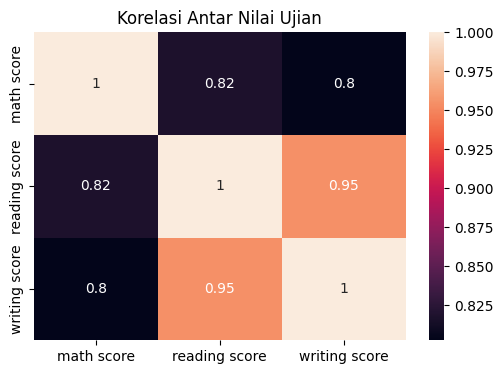

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(), annot=True)
plt.title('Korelasi Antar Nilai Ujian')
plt.show()

Visualisasi data menggunakan grafik Heatmap Korelasi. Angka 1 menunjukkan korelasi sempurna antara variabel dengan variabelnya itu sendiri. Terdapat hubungan kuat antara reading dan writing(0.95) artinya siswa memiliki nilai tinggi pada kedua variabel tersebut, dan diikuti oleh math dan reading(0.82).

## Statistik Deskriptif

In [13]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
print('Parental Level of Education in Average:',df['math score'].mean())
print('Median in Parental Level of Education:',df['math score'].median())
print('Mode in Parental Level of Education:',df['math score'].mode().values[0])


Parental Level of Education in Average: 66.089
Median in Parental Level of Education: 66.0
Mode in Parental Level of Education: 65


Rata-rata nilai matematika berdasarkan pendidikan orangtua sebesar (66.09), nilai median hampir sama dengan nilai rata-rata berarti distribusi nilai matematika cukup simetris. Nilai mode berbeda sedikit.

In [15]:
scores = df[['math score']]
variance = scores.var()
print('Variance of parental level of education:')
print(variance)

Variance of parental level of education:
math score    229.918998
dtype: float64


Hasil analisis menunjukkan Variance tingkat pendidikan orang tua terhadap nilai matematika.

In [16]:
q1 = df['math score'].quantile(0.25)
q3 = df['math score'].quantile(0.75)
iqr = q3 - q1

outliers = ((df[['math score', 'reading score', 'writing score']] < (q1 - 1.5*iqr)) | df[['math score', 'reading score', 'writing score']] > q3 + 1.5*iqr)

outliers_count = outliers.sum()
outliers_count

math score       0
reading score    0
writing score    0
dtype: int64

Mendeteksi jumlah outlier dengan metode Tukey's Rule. Tidak ditemukan outlier yang berarti nilai siswa tersebar secara konsisten khususnya pada nilai matematika.

## Statistik Inferensial

In [17]:
# Menghitung confidence Interval dari nilai matematika
std = df['math score'].std()
N = len(df)
low, up = stats.norm.interval(0.95,loc=df['math score'].mean(),scale=std/np.sqrt(N))
print('Lower Limit:',low)
print('Upper Limit:',up)

Lower Limit: 65.14919982820571
Upper Limit: 67.02880017179429


Rata-rata nilai matematika siswa diperkirakan antara 65.1 hingga 67.5. Jika penelitian ini diulang berkali-kali, 95% interval yang dihasilkan akan mencakup nilai rata-rata sebenarnya.

In [18]:
# Menggunakan independen sample two test
male = df[df['gender'] == 'male']['math score']
female = df[df['gender'] == 'female']['math score']

t_stat, p_val = stats.ttest_ind(male, female)
print('T-Statistic:',t_stat)
print('P-value:',p_val)

T-Statistic: 5.383245869828983
P-value: 9.120185549328822e-08


Disini P-value < 0.05 berarti terdapat perbedaan signifikan antara nilai laki-laki dan perempuan. Dalam hal ini, gender berpengaruh terhadap performa matematika.

# vi. Conclusion

Dari hasil analisis diatas, bisa dibilang nilai siswa dipengaruhi oleh beberapa hal penting. Siswa laki-laki umumnya lebih kuat di matematika sementara perempuan lebih unggul di membaca dan menulis. Nilai juga cenderung lebih bagus kalau orang tuanya punya pendidikan tinggi. Selain itu, kemampuan membaca dan menulis ternyata saling berhubungan kalau jago baca, biasanya jago nulis juga. Jadi, sekolah bisa bantu seimbangin cara belajar biar semua siswa bisa berkembang di semua mata pelajaran. Dukungan dari orang tua dan pola makan yang baik juga penting banget buat bantu nilai anak jadi lebih maksimal.